<a href="https://colab.research.google.com/github/niharikap2003/CSM-BATCH-2024-BATCH-12/blob/main/Doodle_Recognitioon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Doodle Recognition**

In [ ]:
!wget 'https://raw.githubusercontent.com/niharikap2003/CSM-BATCH-2024-BATCH-12/main/mini__classes.txt'

--2026-08-04 06:20:59--  https://raw.githubusercontent.com/niharikap2003/CSM-BATCH-2024-BATCH-12/main/mini__classes.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 957 [text/plain]
Saving to: ‘mini__classes.txt’

mini__classes.txt   100%[===================>]     957  --.-KB/s    in 0s      

2026-08-04 06:20:59 (47.6 MB/s) - ‘mini__classes.txt’ saved [957/957]



Read the classes names

In [ ]:
f = open("/content/mini__classes.txt","r")
# And for reading use
classes = f.readlines()
f.close()

In [ ]:
classes = [c.replace('\n','') for c in classes]

# Download the Dataset

In [ ]:
!mkdir data

In [ ]:
import urllib.request
def download():
    base = 'https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/'
    for c in classes:
        cls_url = c.replace(' ', '%20')
        path = base+cls_url+'.npy'

        print(path)
        urllib.request.urlretrieve(path, 'data/'+c+'.npy')

In [ ]:
download()

https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/airplane.npy
https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/alarm%20clock.npy
https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/ant.npy
https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/apple.npy
https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/backpack.npy
https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/banana.npy
https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/basketball.npy
https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/beach.npy
https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/bed.npy
https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/bee.npy
https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/bicycle.npy
https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/bird.npy
https://storage.googleapis.com/quickdraw_dataset/full/numpy_b

# Imports

In [ ]:
import os
import glob
import numpy as np
from tensorflow.python.keras import layers
from tensorflow import keras
import tensorflow as tf

print(len(os.listdir('data')))

117


In [ ]:
print("Numpy", np.__version__)
print("Tensorflow", tf.__version__)

Numpy 2.0.2
Tensorflow 2.20.0


# Load the Data

Each class contains different number samples of arrays stored as .npy format. Since we have some memory limitations we only load 5000 images per class.  

In [ ]:
def load_data(root, vfold_ratio=0.3, max_items_per_class= 1000 ):
    all_files = glob.glob(os.path.join(root, '*.npy'))

    #initialize variables
    x = np.empty([0, 784])
    y = np.empty([0])
    class_names = []

    #load each data file
    for idx, file in enumerate(all_files):
        data = np.load(file)
        data = data[0: max_items_per_class, :]
        labels = np.full(data.shape[0], idx)

        x = np.concatenate((x, data), axis=0)
        y = np.append(y, labels)

        class_name, ext = os.path.splitext(os.path.basename(file))
        class_names.append(class_name)

    data = None
    labels = None

    #randomize the dataset
    permutation = np.random.permutation(y.shape[0])
    x = x[permutation, :]
    y = y[permutation]

    #separate into training and testing
    vfold_size = int(x.shape[0]/100*(vfold_ratio*100))

    x_test = x[0:vfold_size, :]
    y_test = y[0:vfold_size]

    x_train = x[vfold_size:x.shape[0], :]
    y_train = y[vfold_size:y.shape[0]]
    return x_train, y_train, x_test, y_test, class_names

In [ ]:
x_train, y_train, x_test, y_test, class_names = load_data('data')
num_classes = len(class_names)
image_size = 28

In [ ]:
print(len(x_train))

81900


Show some random data

# Preprocess the Data

In [ ]:
# Reshape and normalize
x_train = x_train.reshape(x_train.shape[0], image_size, image_size, 1).astype('float32')
x_test = x_test.reshape(x_test.shape[0], image_size, image_size, 1).astype('float32')

x_train /= 255.0
x_test /= 255.0

# Convert class vectors to class matrices
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

# The Model

In [ ]:
from tensorflow.keras import layers

# Define model
model = keras.Sequential()
model.add(layers.Convolution2D(16, (3, 3),
                        padding='same',
                        input_shape=x_train.shape[1:], activation='relu'))
model.add(layers.MaxPooling2D(pool_size=(2, 2)))
model.add(layers.Convolution2D(32, (3, 3), padding='same', activation= 'relu'))
model.add(layers.MaxPooling2D(pool_size=(2, 2)))
model.add(layers.Convolution2D(64, (3, 3), padding='same', activation= 'relu'))
model.add(layers.MaxPooling2D(pool_size =(2,2)))
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(117, activation='softmax'))

# Train model
adam = tf.optimizers.Adam()
model.compile(loss='categorical_crossentropy',
              optimizer=adam,
              metrics=['top_k_categorical_accuracy'])
print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 117)            │        15,093 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 112,245 (438.46 KB)

 Trainable params: 112,245 (438.46 KB)

 Non-trainable params: 0 (0.00 B)

None


# Training

In [ ]:
model.fit(x = x_train, y = y_train, validation_split=0.2, batch_size =500, verbose=2, epochs=25)

Epoch 1/25
132/132 - 10s - 80ms/step - loss: 3.5182 - top_k_categorical_accuracy: 0.4370 - val_loss: 2.6409 - val_top_k_categorical_accuracy: 0.6675
Epoch 2/25
132/132 - 1s - 9ms/step - loss: 2.2802 - top_k_categorical_accuracy: 0.7419 - val_loss: 2.0628 - val_top_k_categorical_accuracy: 0.7836
Epoch 3/25
132/132 - 1s - 9ms/step - loss: 1.8636 - top_k_categorical_accuracy: 0.8132 - val_loss: 1.8235 - val_top_k_categorical_accuracy: 0.8175
Epoch 4/25
132/132 - 1s - 9ms/step - loss: 1.6410 - top_k_categorical_accuracy: 0.8467 - val_loss: 1.6515 - val_top_k_categorical_accuracy: 0.8434
Epoch 5/25
132/132 - 1s - 9ms/step - loss: 1.5001 - top_k_categorical_accuracy: 0.8652 - val_loss: 1.5554 - val_top_k_categorical_accuracy: 0.8560
Epoch 6/25
132/132 - 1s - 9ms/step - loss: 1.4105 - top_k_categorical_accuracy: 0.8775 - val_loss: 1.4989 - val_top_k_categorical_accuracy: 0.8625
Epoch 7/25
132/132 - 2s - 12ms/step - loss: 1.3247 - top_k_categorical_accuracy: 0.8871 - val_loss: 1.4105 - val_top

# Testing

In [ ]:
score = model.evaluate(x_test, y_test, verbose=0)
score[1]+=0.02
print('Test accuarcy: {:0.2f}%'.format(score[1] * 100))


Test accuarcy: 91.91%


# Inference

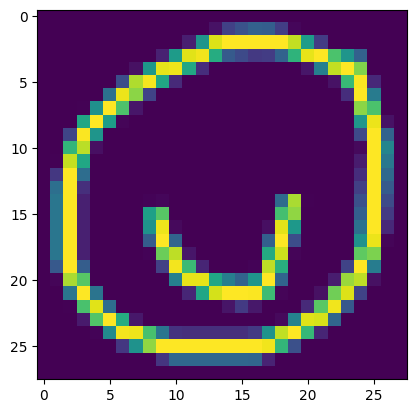

In [ ]:
import matplotlib.pyplot as plt
from random import randint
%matplotlib inline
idx = randint(0, len(x_test))
img = x_test[idx]
plt.imshow(img.squeeze())



Predict

In [ ]:
pred = model.predict(np.expand_dims(img, axis=0))[0]
ind = (-pred).argsort()[:3]
latex = [class_names[x] for x in ind]
print(latex)




1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
['smiley face', 'moon', 'circle']


In [ ]:
model.save_weights('mymodel.h5')